In [106]:
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from scipy.optimize import minimize, Bounds
from delayed_reactant_labeling.optimize import RateConstantOptimizerTemplate
from delayed_reactant_labeling.predict import DRL

experimental_complete = pd.read_excel('MAH233_DRL3.xlsx', engine='openpyxl')
LABEL = "d5"  # single ' was used for labeled reactants. To keep the code general, we will use LABEL instead.

TIME_OF_ADDITION_COMPOUND = 0.87
TIME_LABELED_ADDITION = 20.46
labeled_chemicals = [chemical for chemical in experimental_complete.columns if chemical[-1] == LABEL]
index_compound = np.argmax(np.array(experimental_complete["time (min)"] > TIME_OF_ADDITION_COMPOUND))
index_labeled_addition = np.argmax(np.array(experimental_complete['time (min)'] > TIME_LABELED_ADDITION))  # select first true value
for col in experimental_complete.columns:  # correct for noise by removing the median
    if col == 'time (min)' or col[-len(LABEL):] != LABEL:
        continue
    experimental_complete.loc[:, col] = experimental_complete.loc[:, col] \
        - experimental_complete.loc[index_labeled_addition-10:index_labeled_addition, col].median()

time_pre = experimental_complete.loc[index_compound:index_labeled_addition, "time (min)"].to_numpy()
experimental = experimental_complete.loc[index_labeled_addition:, :]
time = experimental['time (min)'].to_numpy()

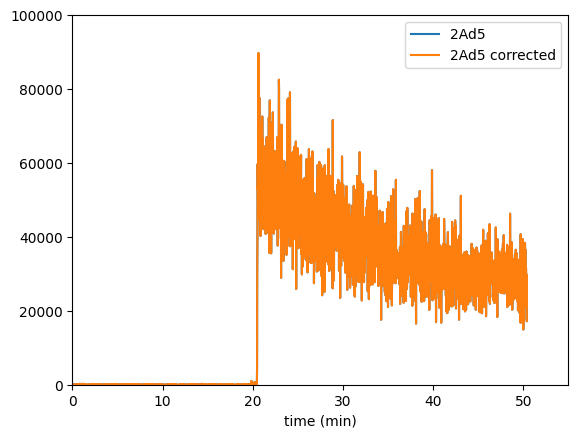

In [107]:
ax = experimental_complete.plot('time (min)', f'2A{LABEL}')

index_labeled_addition = np.argmax(np.array(experimental_complete['time (min)'] > TIME_LABELED_ADDITION))  # select first true value
for col in experimental_complete.columns:  # correct for noise by removing the median
    if col == 'time (min)' or col[-len(LABEL):] != LABEL:
        continue
    experimental_complete.loc[:, col] = experimental_complete.loc[:, col] \
                                        - experimental_complete.loc[index_labeled_addition-10:index_labeled_addition, col].median()

experimental_complete.plot('time (min)', f'2A{LABEL}', ax=ax, label=f'2A{LABEL} corrected')
ax.set_xlim(0, 55)
ax.set_ylim(-0.05, 100000)
#ax.figure.show()

time_pre = experimental_complete.loc[:index_labeled_addition, 'time (min)'].to_numpy()  # pre addition
experimental = experimental_complete.loc[index_labeled_addition:, :]
time = experimental['time (min)'].to_numpy()

(0.0, 104.99733901011382)

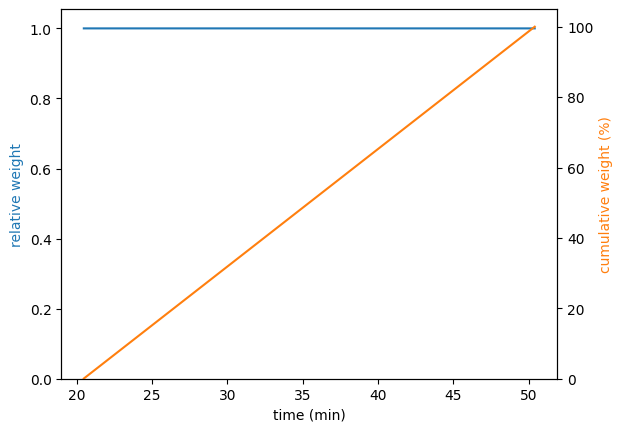

In [108]:
WEIGHT_TIME = 1 - 0 * np.linspace(0, 1, time.shape[0])  # decrease weight with time, first point 10 times as import as last point
WEIGHT_TIME = WEIGHT_TIME / sum(WEIGHT_TIME)  # normalize

def METRIC(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.average(np.abs(y_pred - y_true), weights=WEIGHT_TIME, axis=0)

fig, ax = plt.subplots()
ax.set_xlabel('time (min)')
ax.plot(time, WEIGHT_TIME / max(WEIGHT_TIME), color='C0')
ax.set_ylabel('relative weight', color='C0')
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
ax2.plot(time, WEIGHT_TIME.cumsum() * 100, color='C1')
ax2.set_ylabel('cumulative weight (%)', color='C1')
ax2.set_ylim(bottom=0)
#fig.show()

C:\Users\mhellinghuizen\AppData\Local\Temp\ipykernel_14192\1585365458.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


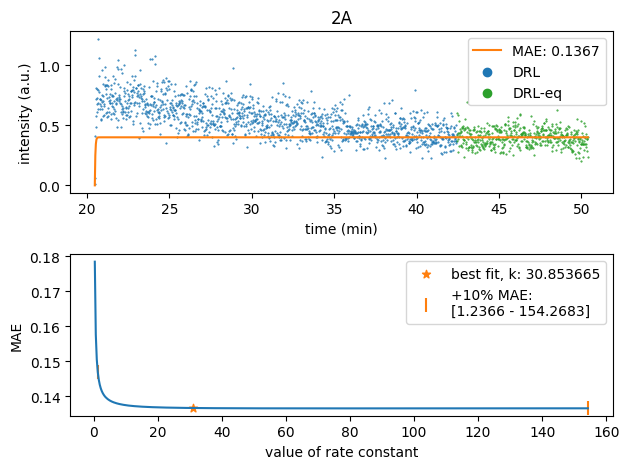

In [109]:
STEADY_STATE_CHEMICALS = ['2A',]
EQUILIBRIUM_LAST_N = 500

for chemical in STEADY_STATE_CHEMICALS:
    # normalize for each steady state such that chemical + chemical' = 1 at equilibrium
    y_true_curve = experimental[f'{chemical}{LABEL}'] / experimental.loc[-EQUILIBRIUM_LAST_N:, [chemical, f'{chemical}{LABEL}']].sum(axis=1).mean()
    f = lambda k: y_true_curve.iloc[-EQUILIBRIUM_LAST_N:].mean() * (1 - np.exp( -k * (time - time[0])))
    MAE_f = lambda x: METRIC(y_true=y_true_curve, y_pred=f(x))

    result = minimize(MAE_f, x0=np.array([1]))
    if not result.success: print(chemical, result.message)

    # show best fit
    fig, axs = plt.subplots(2, 1)
    ax = axs[0]
    ax.set_title(chemical)
    ax.plot(time, f(result.x[0]), label=f'MAE: {result.fun:.4f}', color='tab:orange')
    ax.scatter(time[:-EQUILIBRIUM_LAST_N], y_true_curve[:-EQUILIBRIUM_LAST_N],s=1, marker='.', color='tab:blue')
    ax.scatter(time[-EQUILIBRIUM_LAST_N:], y_true_curve[-EQUILIBRIUM_LAST_N:],s=1, marker='.', color='tab:green')
    ax.scatter(np.nan, np.nan, marker='o', color='tab:blue', label='DRL')  # clearer legend
    ax.scatter(np.nan, np.nan, marker='o', color='tab:green', label='DRL-eq')

    ax.set_xlabel('time (min)')
    ax.set_ylabel('intensity (a.u.)')
    ax.legend()

    # analyze sensitivity to deviations
    rates = np.linspace(0, 5*result.x[0], num=500)
    errors = np.array([MAE_f(x) for x in rates])
    ind = errors < 2.5*result.fun
    ax = axs[1]
    ax.plot(rates[ind], errors[ind])
    ax.scatter(result.x[0], result.fun, label=f'best fit, k: {result.x[0]:.6f}', marker='*', color='tab:orange')
    bounds_10pc = np.where(errors<1.1*result.fun)[0][[0, -1]]
    ax.scatter(rates[bounds_10pc], errors[bounds_10pc], marker='|', color='tab:orange', s=100,
               label=f'+10% MAE:\n[{rates[bounds_10pc[0]]:.4f} - {rates[bounds_10pc[1]]:.4f}]')
    ax.set_xlabel('value of rate constant')
    ax.set_ylabel('MAE')
    ax.legend()
    fig.tight_layout()
    fig.show()

In [110]:
REACTIONS_ONEWAY = []
for label in ['', LABEL]:
    REACTIONS_ONEWAY.extend([
        ("k1", ["cat", f"1{label}", ], [f"2A{label}", ]),

        ("k2", [f"2A{label}", "nitrone", ], [f"3A{label}", ]),

        ("k3", [f"3A{label}", ], [f"4A{label}", "cat"]),

        #("k4", [f"2A{label}", ], [f"5A{label}", ]),
        
        #("k5", [f"3A{label}", ], [f"6A{label}", ]),
        
        ("k6", [f"2A{label}", "cat", ], [f"7A{label}", ]),
    ])

reactions = deepcopy(REACTIONS_ONEWAY)
for k, reactants, products in REACTIONS_ONEWAY:
    reactions.append(("k-" + k[1:], products, reactants))  # 'kABC' reactants, products -> 'k-ABC', products, reactants
rate_constant_names = sorted(set([k for k, _, _ in reactions]))

# these groups will make the analysis easier
ISOMERS = ["A", ]
INTERMEDIATES = ["2", "3", "7",]

In [112]:
from __future__ import annotations  # compatibility with 3.8
WEIGHTS = {
    "ratio_label": 1,
    "ratio_isomer": 0,
    "TIC": 0.2,
    #"7": 2,
}
# By putting it outside the function, we can store in the metadata of each optimization process.
CONCENTRATIONS_INITIAL = {"cat": 0.002 * 200 / 1800,  # concentration in M
                          "nitrone": 0.050 * 200 / 1800,
                          "1": 0.005 * 200 / 1800}
CONCENTRATION_LABELED_REACTANT = {"1d5": 1.19 * 0.005 * 200 / 2000}
DILUTION_FACTOR = 1800 / 2000

class RateConstantOptimizer(RateConstantOptimizerTemplate):
    @staticmethod
    def create_prediction(x: np.ndarray, x_description: list[str]) -> pd.DataFrame:
        # separate out the ionization factor from the other parameters which are being optimized.
        rate_constants = pd.Series(x[:len(rate_constant_names)], index=x_description[:len(rate_constant_names)])
        ionization_factor_1 = x[-2]
        ionization_factor_2 = x[-1]

        drl = DRL(reactions=reactions,
                  rate_constants=rate_constants,
                  verbose=False)

        prediction_labeled = drl.predict_concentration(
            t_eval_pre=time_pre,
            t_eval_post=time,
            initial_concentrations=CONCENTRATIONS_INITIAL,
            labeled_concentration=CONCENTRATION_LABELED_REACTANT,
            dilution_factor=DILUTION_FACTOR,
            rtol=1e-8,
            atol=1e-8)

        # SYSTEM-SPECIFIC ENAMINE IONIZATION CORRECTION -> only a prediction of 4 and 5 together can be made!
        # this because the unstable enamine will ionize to the iminium ion upon injection in the mass spectrometer.
        #for isomer in ISOMERS:
        #    for label in ["", LABEL]:
        #        prediction_labeled.loc[:, f"2/5{isomer}{label}"] = prediction_labeled.loc[:, f"2{isomer}{label}"] \
        #            + ionization_factor_1 * prediction_labeled.loc[:, f"5{isomer}{label}"]
        #        
        #        prediction_labeled.loc[:, f"3/6{isomer}{label}"] = prediction_labeled.loc[:, f"3{isomer}{label}"] \
        #            + ionization_factor_2 * prediction_labeled.loc[:, f"6{isomer}{label}"]

        return prediction_labeled

    @staticmethod
    def calculate_curves(data: pd.DataFrame) -> dict[str, np.ndarray]:
        curves = {}
        for intermediate in INTERMEDIATES:
            # sum does not have to be recalculated between the isomer runs
            sum_all_isomers = data[[f'{intermediate}{isomer}' for isomer in ISOMERS]].sum(axis=1)
            for isomer in ISOMERS:
                chemical = f"{intermediate}{isomer}"  # 3D, 3E, 3F, 4/5D, 4/5E, 3/5F
                # allows for easy modification of weight. str.contains('int_1') is much more specific than just '1'
                chemical_iso_split = f"int_{intermediate}_iso_{isomer}"

                sum_chemical = data[[chemical, f"{chemical}{LABEL}"]].sum(axis=1)

                curves[f"ratio_label_{chemical_iso_split}"] = (  # 3D / (3D+3D')
                    data[chemical] / sum_chemical).to_numpy()
                curves[f"ratio_isomer_{chemical_iso_split}"] = (  # 3D / (3D+3E+3F)
                    data[chemical] / sum_all_isomers).to_numpy()
                curves[f"TIC-normal_{chemical_iso_split}"] = (  # normalized TIC curve
                        data[chemical] / sum_chemical.iloc[-100:].mean()).to_numpy()
                curves[f"TIC-labeled_{chemical_iso_split}"] = (  # normalized TIC curve
                        data[f"{chemical}{LABEL}"] / sum_chemical.iloc[-100:].mean()).to_numpy()
        return curves

    def weigh_errors(self, errors: pd.Series) -> pd.Series:
        weighed_errors = super().weigh_errors(errors)

        # perform the usual behavior of this function, but also perform an additional check with regards to the output!
        TIC_sum = weighed_errors[weighed_errors.index.str.contains("TIC-")].sum()
        label_sum = weighed_errors[weighed_errors.index.str.contains("label_")].sum()
        isomer_sum = weighed_errors[weighed_errors.index.str.contains("isomer_")].sum()
        total = TIC_sum + label_sum + isomer_sum
        ratios = pd.Series([TIC_sum/total, label_sum/total, isomer_sum/total], index=['TIC', 'label', 'total'])
        #if any(ratios < 0.05) or any(ratios > 0.95):
        #    warnings.warn(f'One of the error metrics is either way smaller, or way larger than the others\n{ratios}')

        return weighed_errors

RCO = RateConstantOptimizer(experimental=experimental, metric=METRIC, raw_weights=WEIGHTS)

In [113]:
dimension_descriptions = list(rate_constant_names) #+ ["ion1"] + ["ion2"]
constraints = pd.DataFrame(np.full((len(dimension_descriptions), 3), np.nan),
                           columns=["x0", "lower", "upper"],
                           index=dimension_descriptions)

index_reverse_reaction = constraints.index.str.contains("k-")
constraints.iloc[np.nonzero(~index_reverse_reaction)] = [1, 1e-9, 5e2]  # forwards; vertex, lower, upper
constraints.iloc[np.nonzero(index_reverse_reaction)] = [0.5, 0, 5e2]    # backwards
# newer versions of pandas could also use:
# constraints[~index_reverse_reaction] = [1, 1e-9, 1e2]

# special case
#constraints.iloc[np.nonzero(constraints.index.str.contains("ion"))] = [0.01, 1e-6, 1]

#constraints.iloc[np.nonzero(constraints.index.str.contains("k2_D"))] = [0.441673, 0.4160, 0.4780]
#constraints.iloc[np.nonzero(constraints.index.str.contains("k2_E"))] = [0.782919, 0.6747, 0.9335]
#constraints.iloc[np.nonzero(constraints.index.str.contains("k2_F"))] = [0.464105, 0.2418, 1.2277]

# either chemically or experimentally determined to be zero
constraints.iloc[np.nonzero(constraints.index.str.contains("k-2"))] = [0, 0, 0]
constraints.iloc[np.nonzero(constraints.index.str.contains("k-6"))] = [0, 0, 0]
#constraints.iloc[np.nonzero(constraints.index.str.contains("k-3"))] = [0, 0, 0]
x0 = constraints["x0"].to_numpy()
bounds = Bounds(constraints['lower'].to_numpy(), constraints['upper'].to_numpy())

In [114]:
path = './MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization'
RCO.optimize(
    x0=x0,
    x_description=dimension_descriptions,
    x_bounds=bounds,
    path=path,
    maxiter=100000,  # this might take a while ...
)

  1%|▏         | 1415/100000 [00:42<49:19, 33.32it/s] 


In [115]:
RCO.optimize_multiple(
    path='./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization_multiple',
    n_runs=200,  # This take a long while ...
    x_description=dimension_descriptions,
    x_bounds=bounds,
    maxiter=100000,
    n_jobs=-1,   # uses all but 1 cpu cores available; this took a day or 2 ...
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   27.9s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   33.9s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   57.0s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   57.4s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   59.8s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  2

In [116]:
from delayed_reactant_labeling.optimize import OptimizedMultipleModels
from delayed_reactant_labeling.optimize import OptimizedModel
from delayed_reactant_labeling.visualize import VisualizeModel

models = OptimizedMultipleModels('./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization_multiple')
model = OptimizedModel('./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization')

200it [00:05, 34.75it/s]


In [ ]:
#Single model
VM = VisualizeModel(
    image_path='./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization/images/',
    model=model,  # this assumption would be made automatically, but raises a warning
    models=None,
    rate_constant_optimizer=RCO,
    hide_params=constraints['upper'] == 0,
    extensions=['.png', 'svg'], overwrite_image=True)  # having a leading '.' does not matter

In [117]:
#Multiple models
VM = VisualizeModel(
    image_path='./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization_multiple/images/',
    model=models.best,  # this assumption would be made automatically, but raises a warning
    models=models,
    rate_constant_optimizer=RCO,
    hide_params=constraints['upper'] == 0,
    extensions=['.png', 'svg'], overwrite_image=True)  # having a leading '.' does not matter

C:\Users\mhellinghuizen\AppData\Local\Temp\ipykernel_14192\415955833.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ionization_factor_1 = x[-2]
C:\Users\mhellinghuizen\AppData\Local\Temp\ipykernel_14192\415955833.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ionization_factor_2 = x[-1]
C:\Users\mhellinghuizen\AppData\Local\Temp\ipykernel_14192\415955833.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ionization_fac

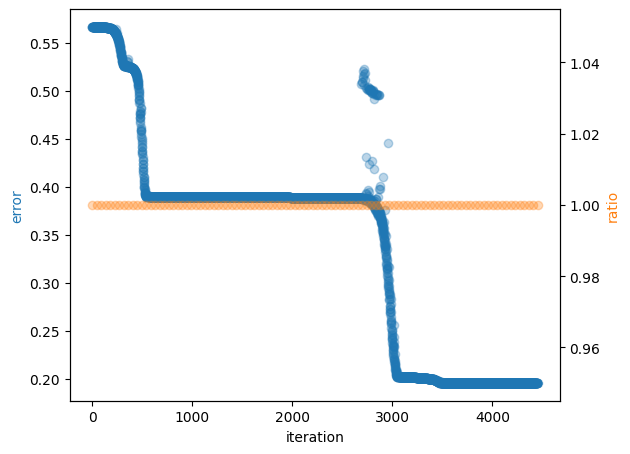

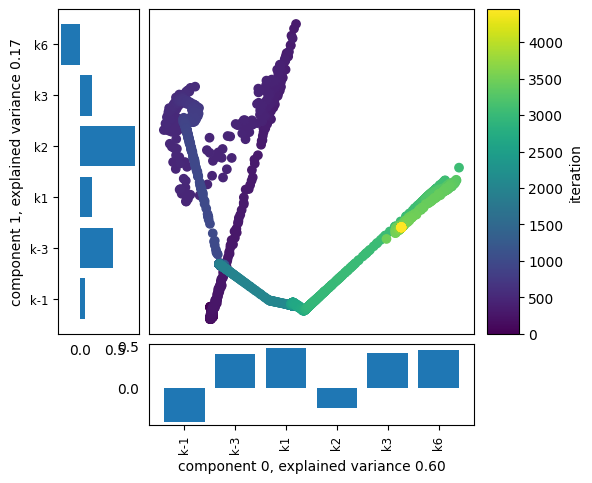

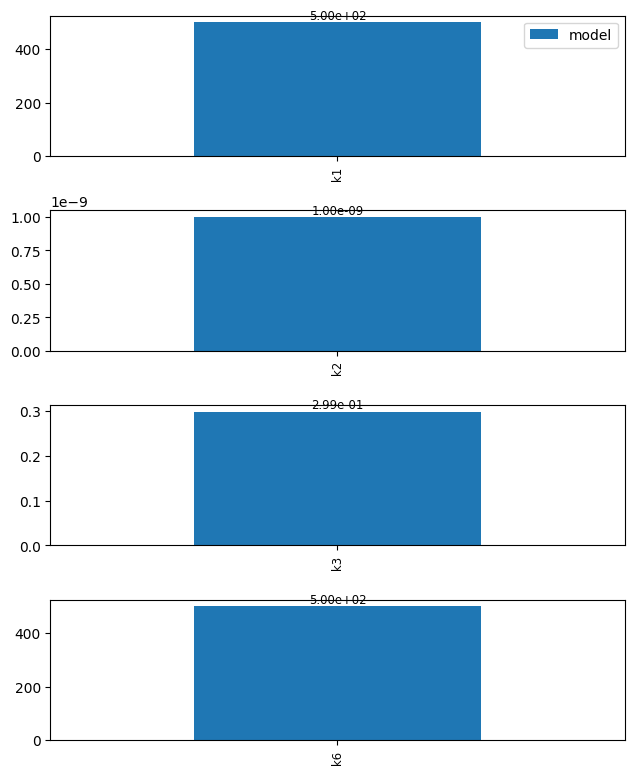

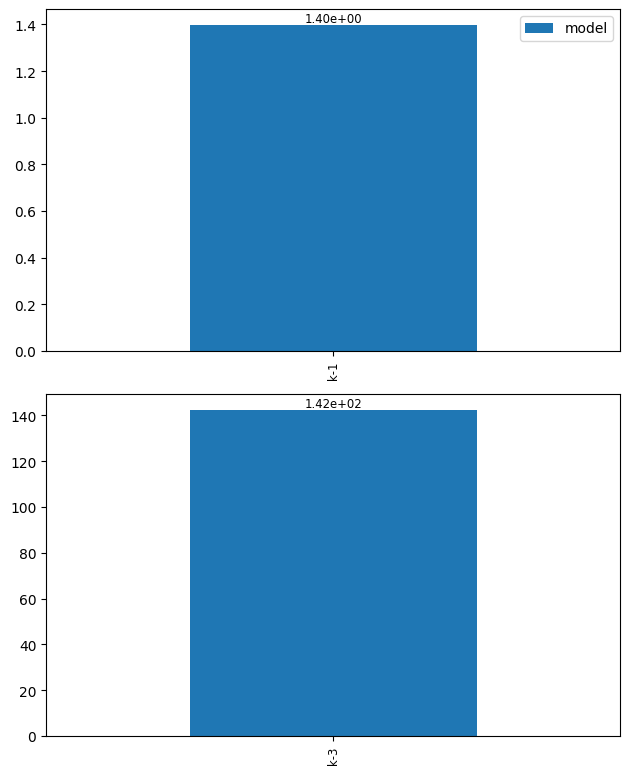

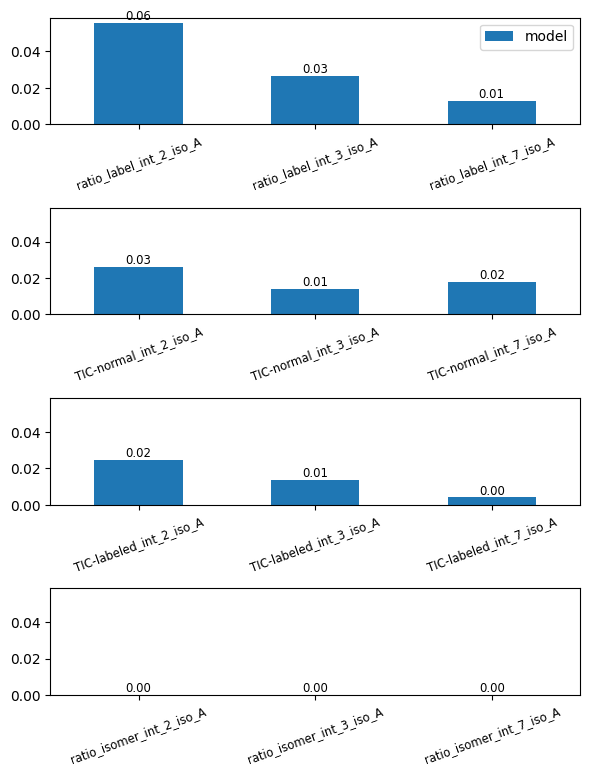

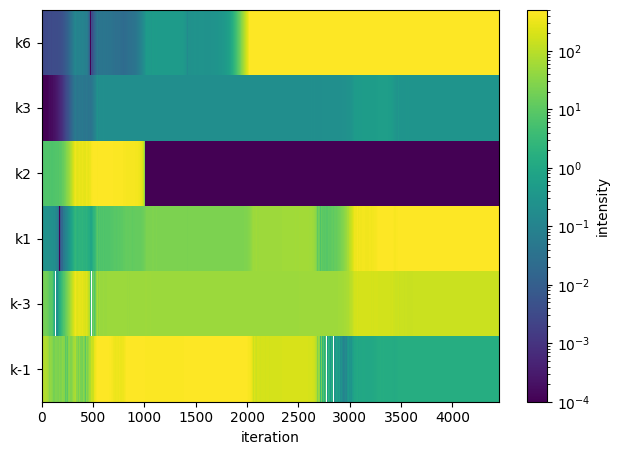

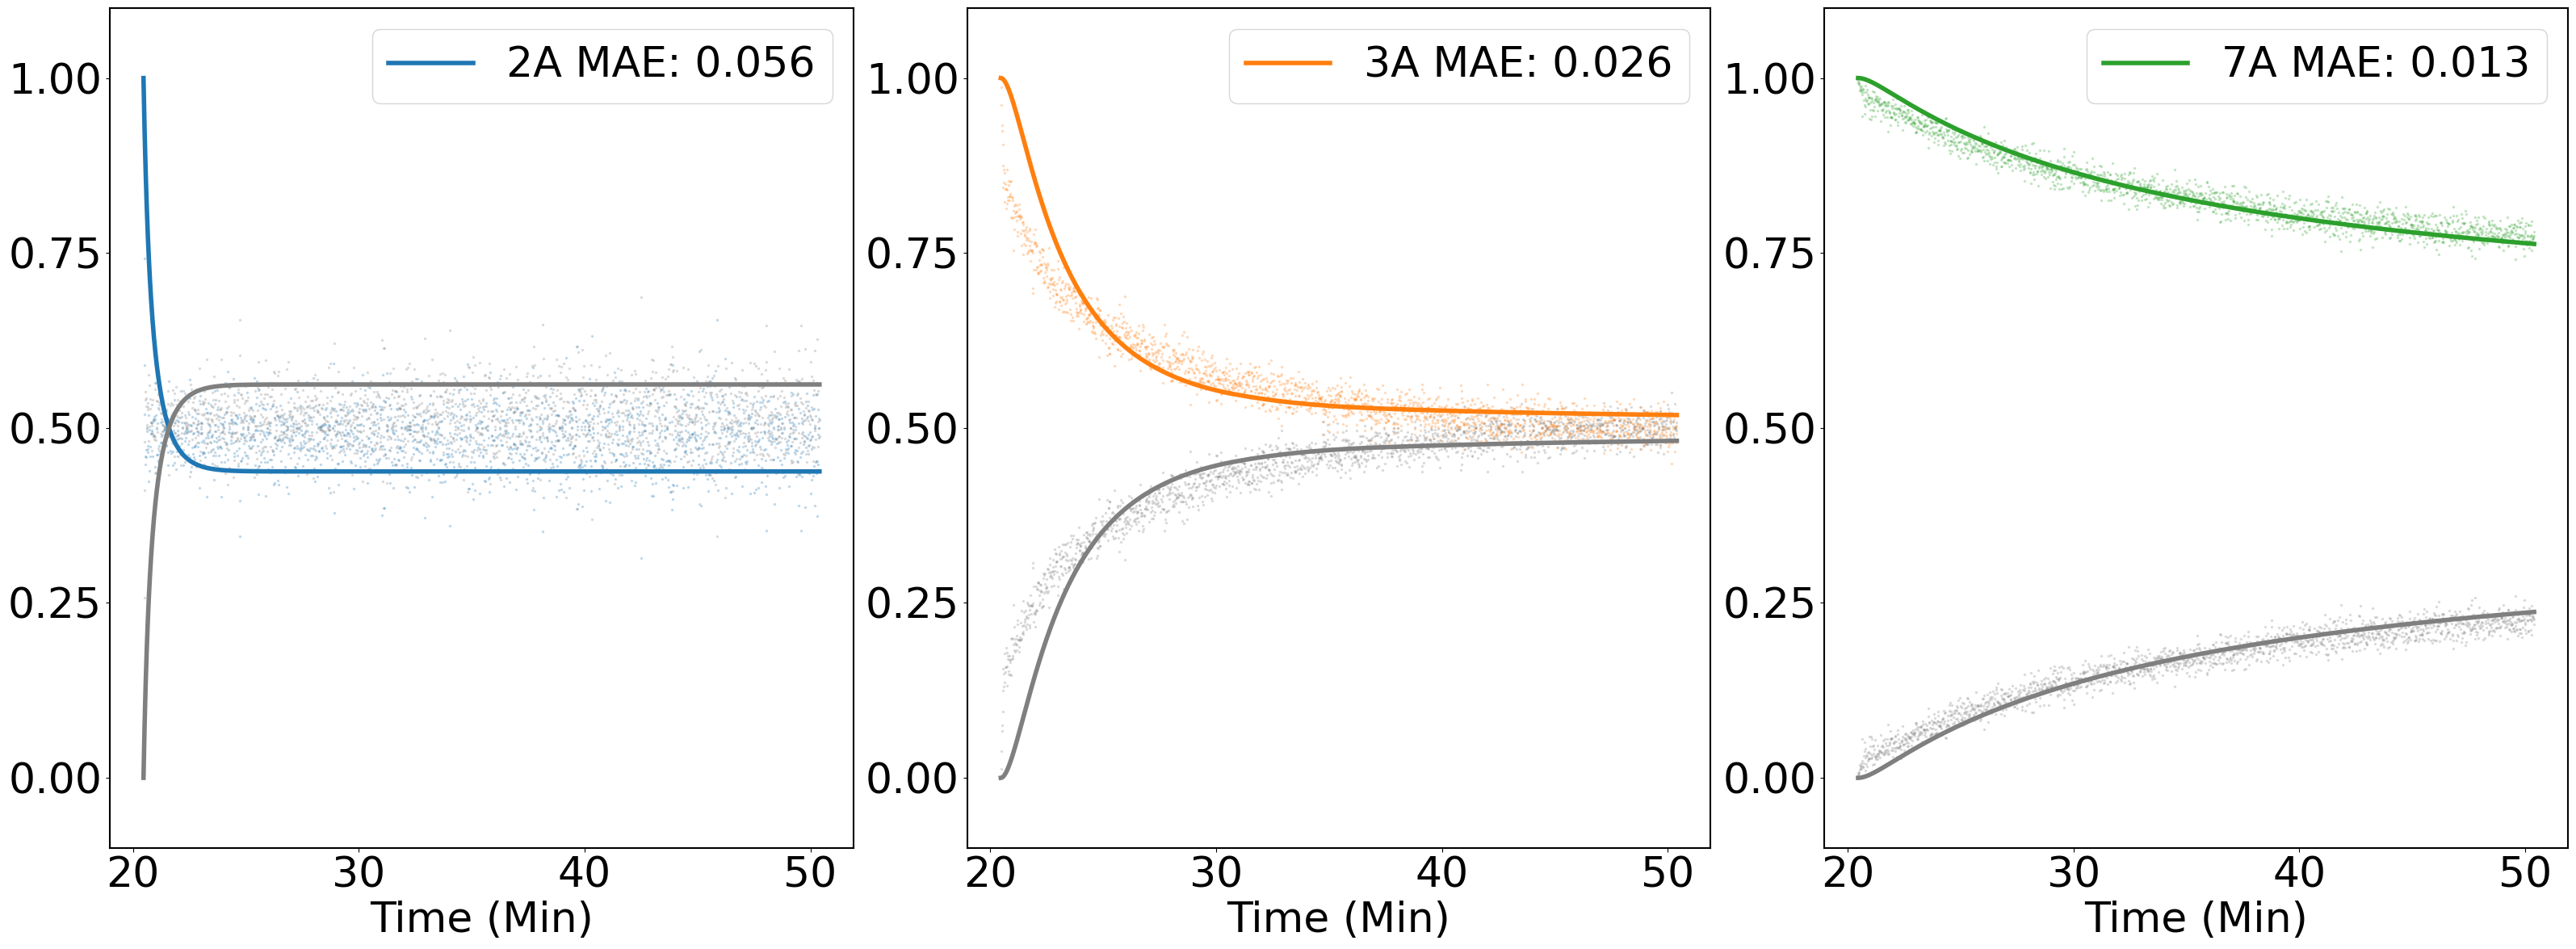

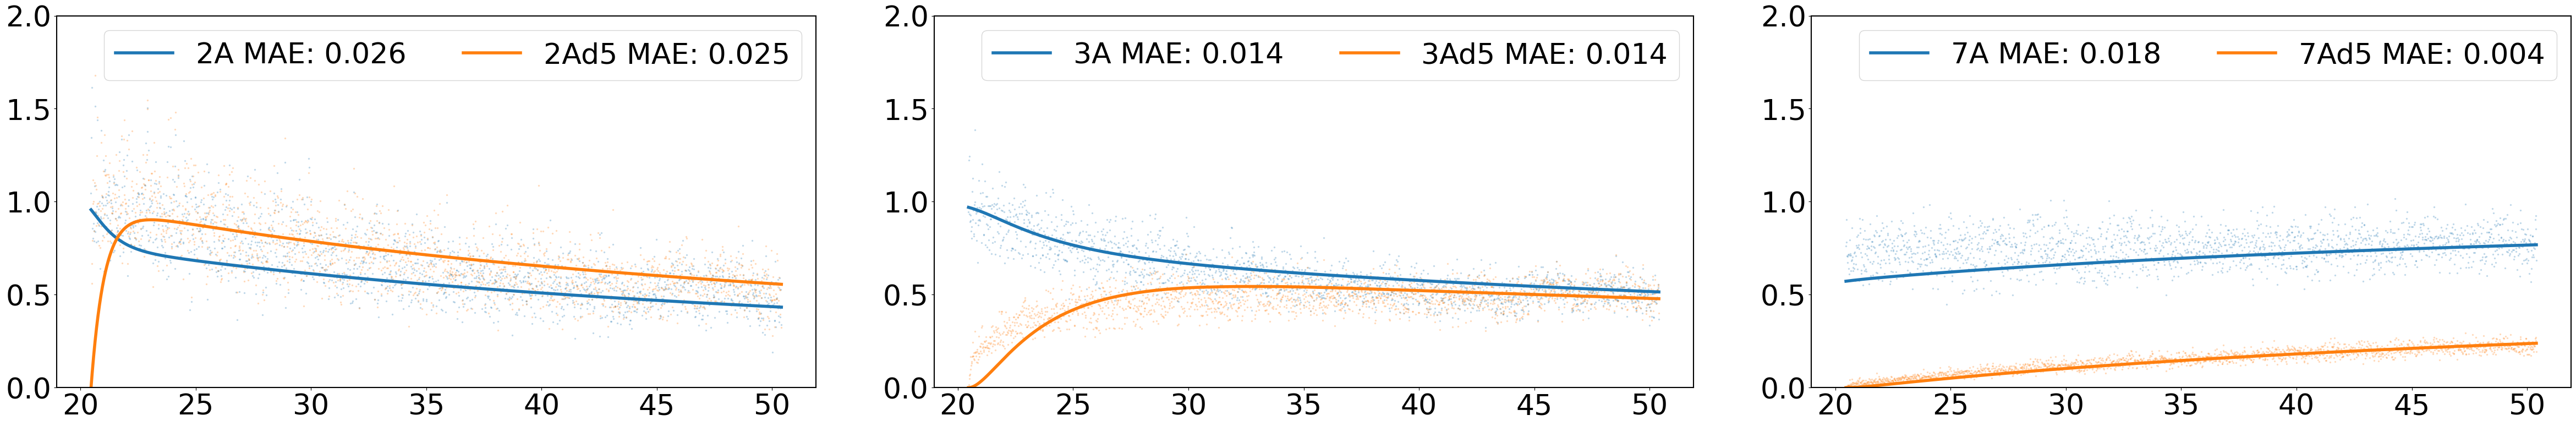

In [119]:
pd.set_option('display.precision', 20)  # or however many decimals you need

VM.plot_optimization_progress(ratio=('4A', ['4A',]))

VM.plot_path_in_pca(pc1=0, pc2=1, figsize=(6.4, 6.4))

VM.plot_grouped_by_sci(
    VM.model.optimal_x.rename('model'),
    group_by=['k1', 'k2', 'k3', 'k6',],
    file_name='plot_x1', xtick_rotation=90, show_remaining=False, figsize=(6.4, 8))

VM.plot_grouped_by_sci(
    VM.model.optimal_x.rename('model'),
    group_by=['k-1', 'k-3',],
    file_name='plot_x2', xtick_rotation=90, show_remaining=False, figsize=(6.4, 8))

model_pred = RCO.create_prediction(VM.model.optimal_x.values, VM.model.optimal_x.index.tolist())
model_weighed_errors = RCO.weigh_errors(errors=RCO.calculate_errors(model_pred)).rename('model')

#Hilgers_pred = RCO.create_prediction(rate_constants_Hilgers.values, rate_constants_Hilgers.index.tolist())
#Hilgers_weighed_errors = RCO.weigh_errors(errors=RCO.calculate_errors(Hilgers_pred)).rename('Hilgers')

VM.plot_grouped_by(
    model_weighed_errors,
    group_by=['ratio_label', 'TIC-normal', 'TIC-labeled'], file_name='plot_errors', xtick_rotation=20,
    figsize=(6, 8), sharey='col')

#fig, ax = VM.plot_enantiomer_ratio(
#    group_by=['2/4', '3/5', '6'],
#    ratio_of=['A', 'B',],
#    experimental=experimental,
#    prediction=model_pred,
#    warn_label_assumption=False)
#ax.set_ylim(0, 1)
#VM.save_image(fig, 'plot_enantiomer_ratio')

VM.plot_rate_over_time(log_scale=True, x_min=1e-4)

LINE = 4
MARKER = 3
AXIS = 1.5
TICK = 37.5
LEGEND = 37.5

def plot_curves(data, errors=None, **style):
    """if errors are given, give each line a label including the error for that curve"""
    plot_label = True if errors is not None else False
    for i, intermediate in enumerate(INTERMEDIATES):
        for j, isomer in enumerate(ISOMERS):
            chemical_iso_split = f"int_{intermediate}_iso_{isomer}"
            chemical = f"{intermediate}{isomer}"

            # plot label ratio, the curve of the labeled compound is the same, by definition, as 1 - unlabeled
            label = f"{chemical} MAE: {errors[f'ratio_label_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_label[j, i].plot(time, data[f"ratio_label_{chemical_iso_split}"], color=f"C{i}", label=label, lw=LINE, **style)
            axs_label[j, i].plot(time, 1 - data[f"ratio_label_{chemical_iso_split}"], color="tab:gray", lw=LINE, **style)

            # isomer ratio
            #label = f"{chemical} MAE: {errors[f'ratio_isomer_{chemical_iso_split}']:.3f}" if plot_label else None
            #axs_isomer[i, 0].plot(time, data[f"ratio_isomer_{chemical_iso_split}"], color=f"C{j}", label=label, **style)

            # TIC shape
            label = f"{chemical} MAE: {errors[f'TIC-normal_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_TIC[j, i].plot(time, data[f"TIC-normal_{chemical_iso_split}"], color="tab:blue", label=label, lw=LINE, **style)

            # TIC labeled shape
            label = f"{chemical}{LABEL} MAE: {errors[f'TIC-labeled_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_TIC[j, i].plot(time, data[f"TIC-labeled_{chemical_iso_split}"], color="tab:orange", label=label, lw=LINE, **style)

# manual plot of curves
fig_label, axs_label = plt.subplots(1, 3, tight_layout=True, figsize=(32, 12), squeeze=False)
for ax in axs_label.flatten():
    ax.set_ylim([-0.1,1.1])
    ax.tick_params(axis='both', which='major', labelsize=TICK)
    ax.set_xlabel("Time (Min)", fontsize=TICK)
    y_ticks = np.linspace(0, 1, 5)  # Create 5 evenly spaced ticks from 0 to 1
    ax.set_yticks(y_ticks)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS)
#fig_isomer, axs_isomer = plt.subplots(2, 1, tight_layout=True, squeeze=False)
#axs_isomer[0, 0].set_title('isomer ratio')
fig_TIC, axs_TIC = plt.subplots(1, 3, tight_layout=True, figsize=(48, 8), squeeze=False)
axs_TIC[0, 1].set_title(None)
for ax in axs_TIC.flatten():
    ax.set_ylim([0,2])
    ax.tick_params(axis='both', which='major', labelsize=TICK)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS)

# experimental
plot_curves(VM.RCO.experimental_curves, linestyle='', marker='.', ms=MARKER, alpha=0.2)

# best model
pred = VM.RCO.create_prediction(VM.model.optimal_x.values, VM.model.optimal_x.index)
curves = VM.RCO.calculate_curves(pred)
errors = VM.RCO.weigh_errors(VM.RCO.calculate_errors(pred))
plot_curves(curves, errors, linestyle='-')

for ax in np.concatenate([axs_label.flatten(), axs_TIC.flatten()]):
    ax.legend(ncol=2, loc='upper right', fontsize=LEGEND)
VM.save_image(fig_label, 'label')
#VM.save_image(fig_isomer, 'isomer')
VM.save_image(fig_TIC, 'TIC')

100%|██████████| 6/6 [01:38<00:00, 16.42s/it]


k-1: CI = [0.7413, 2.951]
k-3: CI = [39.81, 295.1]
k1: CI = [263, 1047]
k2: CI = [1e-06, 21.88]
k3: CI = [0.138, 1e+04]
k6: CI = [263, 912]


(<Figure size 640x480 with 2 Axes>, <Axes: >)

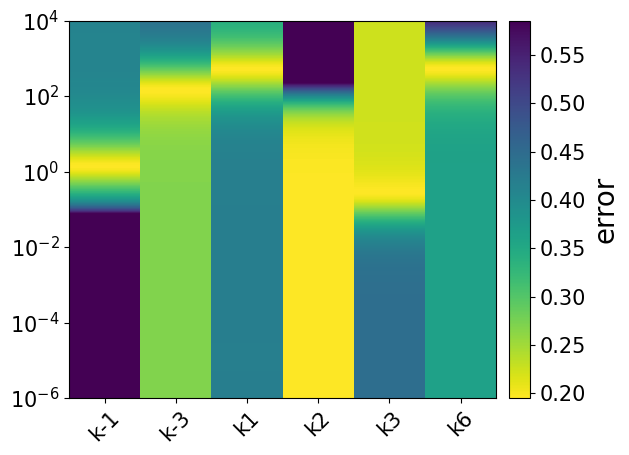

In [123]:
VM.plot_rate_sensitivity(x_min=1e-6, x_max=10000, steps=1001, max_error=None, thresh=1.2)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Solution nr. (sorted by error)', ylabel='error'>)

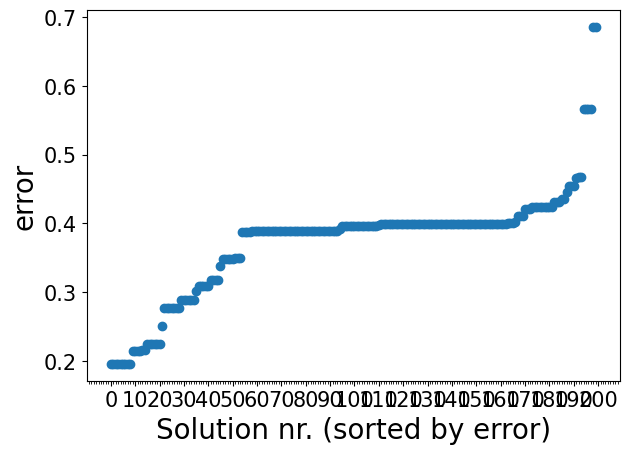

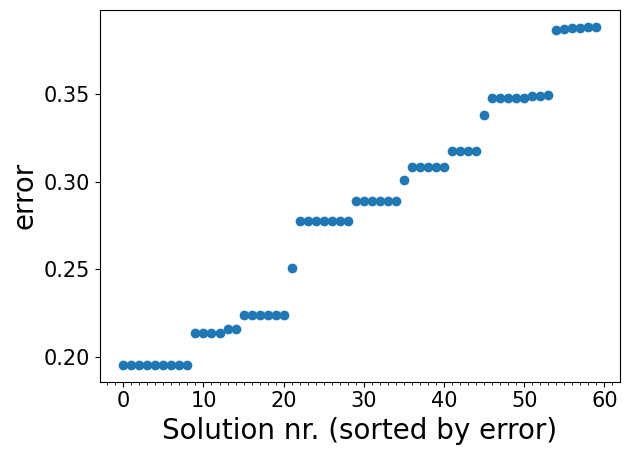

In [120]:
VM.plot_error_all_runs()
VM.plot_error_all_runs(60, file_name='plot_error_all_runs_zoom_in')

#VM.plot_ratio_all_runs(ratio=('6A', ['6A', '6B']), top_n=60)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

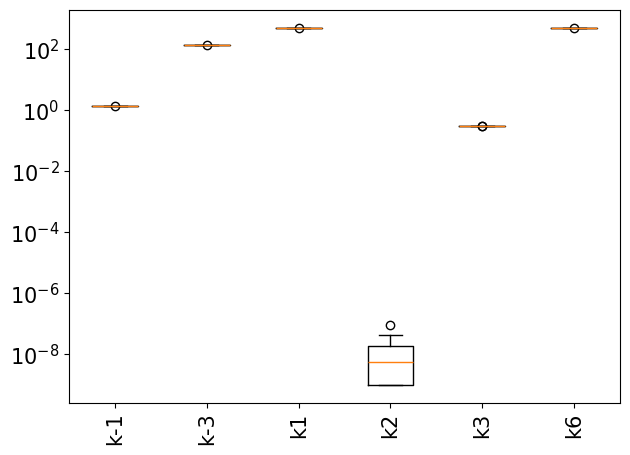

In [121]:
VM.plot_x_all_runs(index=slice(0,8), file_name='best_9')

F:\PhD\DRL Fitting\venv\lib\site-packages\delayed_reactant_labeling\visualize.py:149: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


ValueError: Image size of 3813x450458 pixels is too large. It must be less than 2^16 in each direction.

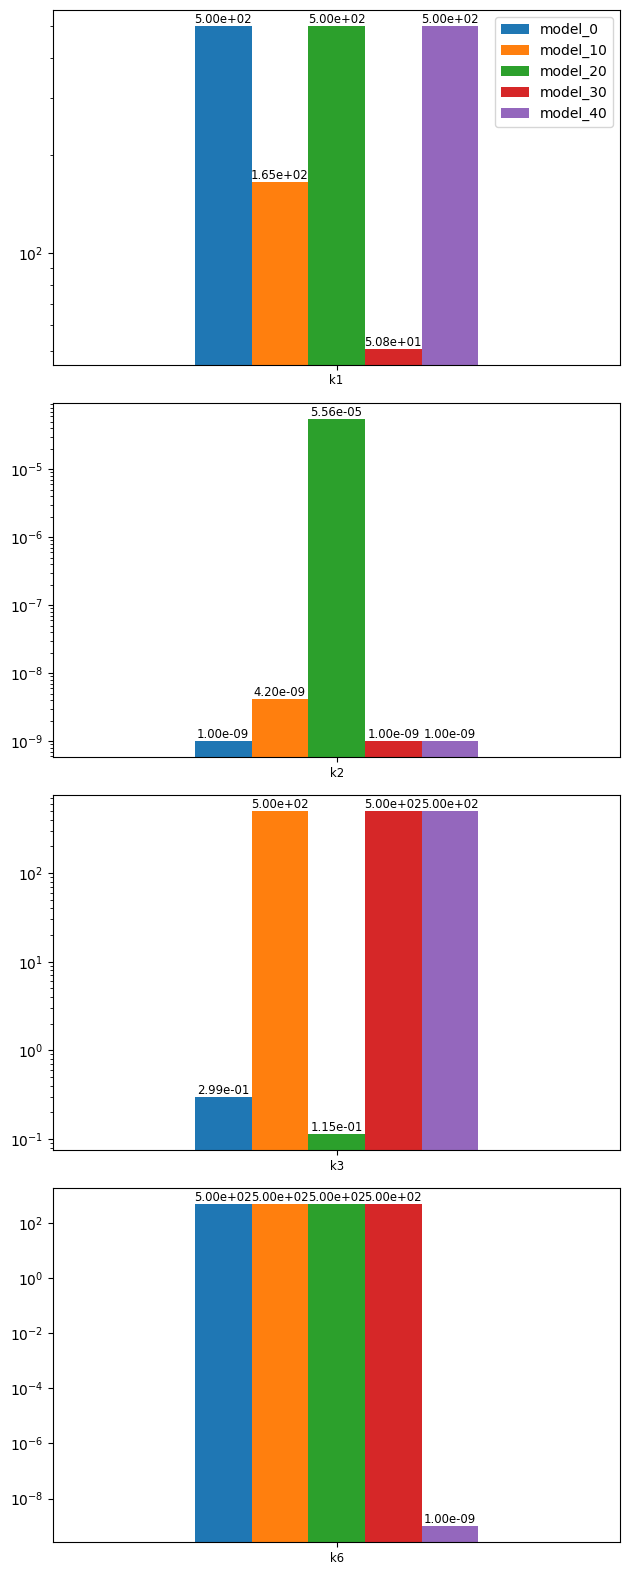

ValueError: Image size of 637x75076 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x1600 with 2 Axes>

In [122]:
fig, axs = VM.plot_grouped_by_sci(
    models.get_model(0).optimal_x.rename('model_0'),
    #models.get_model(5).optimal_x.rename('model_5'),
    models.get_model(10).optimal_x.rename('model_10'),
    models.get_model(20).optimal_x.rename('model_20'),
    models.get_model(30).optimal_x.rename('model_30'),
    models.get_model(40).optimal_x.rename('model_40'),
    #models.get_model(6).optimal_x.rename('model_6'),
    #models.get_model(7).optimal_x.rename('model_7'),
    group_by=['k1', 'k2', 'k3', 'k6',],
    show_remaining=False, figsize=(6.4, 16), file_name='x_comparison_multiple_models_1')
for ax in axs:
    ax.set_yscale('log')
VM.save_image(fig, 'x_comparison_multiple_models_1')

fig, axs = VM.plot_grouped_by_sci(
    models.get_model(0).optimal_x.rename('model_0'),
    #models.get_model(5).optimal_x.rename('model_5'),
    models.get_model(10).optimal_x.rename('model_10'),
    models.get_model(20).optimal_x.rename('model_20'),
    models.get_model(30).optimal_x.rename('model_30'),
    models.get_model(40).optimal_x.rename('model_40'),
    #models.get_model(6).optimal_x.rename('model_6'),
    #models.get_model(7).optimal_x.rename('model_7'),
    group_by=['k-1', 'k-3',],
    show_remaining=False, figsize=(6.4, 16), file_name='x_comparison_multiple_models_2')
for ax in axs:
    ax.set_yscale('log')
VM.save_image(fig, 'x_comparison_multiple_models_2')

In [ ]:
LINE = 4
MARKER = 3
AXIS = 1.5
TICK = 37.5
LEGEND = 37.5

def plot_curves(data, errors=None, **style):
    """if errors are given, give each line a label including the error for that curve"""
    plot_label = True if errors is not None else False
    for i, intermediate in enumerate(INTERMEDIATES):
        for j, isomer in enumerate(ISOMERS):
            chemical_iso_split = f"int_{intermediate}_iso_{isomer}"
            chemical = f"{intermediate}{isomer}"

            # plot label ratio, the curve of the labeled compound is the same, by definition, as 1 - unlabeled
            label = f"{chemical} MAE: {errors[f'ratio_label_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_label[j, i].plot(time, data[f"ratio_label_{chemical_iso_split}"], color=f"C{i}", label=label, lw=LINE, **style)
            axs_label[j, i].plot(time, 1 - data[f"ratio_label_{chemical_iso_split}"], color="tab:gray", lw=LINE, **style)

            # isomer ratio
            #label = f"{chemical} MAE: {errors[f'ratio_isomer_{chemical_iso_split}']:.3f}" if plot_label else None
            #axs_isomer[i, 0].plot(time, data[f"ratio_isomer_{chemical_iso_split}"], color=f"C{j}", label=label, **style)

            # TIC shape
            label = f"{chemical} MAE: {errors[f'TIC-normal_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_TIC[j, i].plot(time, data[f"TIC-normal_{chemical_iso_split}"], color="tab:blue", label=label, lw=LINE, **style)

            # TIC labeled shape
            label = f"{chemical}{LABEL} MAE: {errors[f'TIC-labeled_{chemical_iso_split}']:.3f}" if plot_label else None
            axs_TIC[j, i].plot(time, data[f"TIC-labeled_{chemical_iso_split}"], color="tab:orange", label=label, lw=LINE, **style)

# manual plot of curves
fig_label, axs_label = plt.subplots(1, 3, tight_layout=True, figsize=(32, 12), squeeze=False)
for ax in axs_label.flatten():
    ax.set_ylim([-0.1,1.1])
    ax.tick_params(axis='both', which='major', labelsize=TICK)
    ax.set_xlabel("Time (Min)", fontsize=TICK)
    y_ticks = np.linspace(0, 1, 5)  # Create 5 evenly spaced ticks from 0 to 1
    ax.set_yticks(y_ticks)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS)
#fig_isomer, axs_isomer = plt.subplots(2, 1, tight_layout=True, squeeze=False)
#axs_isomer[0, 0].set_title('isomer ratio')
fig_TIC, axs_TIC = plt.subplots(1, 3, tight_layout=True, figsize=(48, 8), squeeze=False)
axs_TIC[0, 1].set_title(None)
for ax in axs_TIC.flatten():
    ax.set_ylim([0,2])
    ax.tick_params(axis='both', which='major', labelsize=TICK)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS)

# experimental
plot_curves(VM.RCO.experimental_curves, linestyle='', marker='.', ms=MARKER, alpha=0.2)

# best model
pred = VM.RCO.create_prediction(VM.models.get_model(30).optimal_x.values, VM.model.optimal_x.index)
curves = VM.RCO.calculate_curves(pred)
errors = VM.RCO.weigh_errors(VM.RCO.calculate_errors(pred))
plot_curves(curves, errors, linestyle='-')

for ax in np.concatenate([axs_label.flatten(), axs_TIC.flatten()]):
    ax.legend(ncol=2, loc='upper right', fontsize=LEGEND)
VM.save_image(fig_label, 'label_30')
#VM.save_image(fig_isomer, 'isomer')
#VM.save_image(fig_TIC, 'TIC_10')

In [124]:
#To get full predicted concentrations of reactants:
class RateConstantOptimizer(RateConstantOptimizerTemplate):
    @staticmethod
    def create_prediction(x: np.ndarray, x_description: list[str]) -> pd.DataFrame:
        # separate out the ionization factor from the other parameters which are being optimized.
        rate_constants = pd.Series(x[:len(rate_constant_names)], index=x_description[:len(rate_constant_names)])
        ionization_factor_1 = x[-2]
        ionization_factor_2 = x[-1]

        drl = DRL(reactions=reactions,
                  rate_constants=rate_constants,
                  verbose=False)

        prediction_labeled = drl.predict_concentration_full(
            t_eval_pre=time_pre,
            t_eval_post=time,
            initial_concentrations=CONCENTRATIONS_INITIAL,
            labeled_concentration=CONCENTRATION_LABELED_REACTANT,
            dilution_factor=DILUTION_FACTOR,
            rtol=1e-8,
            atol=1e-8)

        # SYSTEM-SPECIFIC ENAMINE IONIZATION CORRECTION -> only a prediction of 4 and 5 together can be made!
        # this because the unstable enamine will ionize to the iminium ion upon injection in the mass spectrometer.
        #for isomer in ISOMERS:
        #    for label in ["", LABEL]:
        #        prediction_labeled.loc[:, f"2/5{isomer}{label}"] = prediction_labeled.loc[:, f"2{isomer}{label}"] \
        #            + ionization_factor_1 * prediction_labeled.loc[:, f"5{isomer}{label}"]
        #        
        #        prediction_labeled.loc[:, f"3/6{isomer}{label}"] = prediction_labeled.loc[:, f"3{isomer}{label}"] \
        #            + ionization_factor_2 * prediction_labeled.loc[:, f"6{isomer}{label}"]

        return prediction_labeled

    @staticmethod
    def calculate_curves(data: pd.DataFrame) -> dict[str, np.ndarray]:
        curves = {}
        for intermediate in INTERMEDIATES:
            # sum does not have to be recalculated between the isomer runs
            sum_all_isomers = data[[f'{intermediate}{isomer}' for isomer in ISOMERS]].sum(axis=1)
            for isomer in ISOMERS:
                chemical = f"{intermediate}{isomer}"  # 3D, 3E, 3F, 4/5D, 4/5E, 3/5F
                # allows for easy modification of weight. str.contains('int_1') is much more specific than just '1'
                chemical_iso_split = f"int_{intermediate}_iso_{isomer}"

                sum_chemical = data[[chemical, f"{chemical}{LABEL}"]].sum(axis=1)

                curves[f"ratio_label_{chemical_iso_split}"] = (  # 3D / (3D+3D')
                    data[chemical] / sum_chemical).to_numpy()
                curves[f"ratio_isomer_{chemical_iso_split}"] = (  # 3D / (3D+3E+3F)
                    data[chemical] / sum_all_isomers).to_numpy()
                curves[f"TIC-normal_{chemical_iso_split}"] = (  # normalized TIC curve
                        data[chemical] / sum_chemical.iloc[-100:].mean()).to_numpy()
                curves[f"TIC-labeled_{chemical_iso_split}"] = (  # normalized TIC curve
                        data[f"{chemical}{LABEL}"] / sum_chemical.iloc[-100:].mean()).to_numpy()
        return curves

    def weigh_errors(self, errors: pd.Series) -> pd.Series:
        weighed_errors = super().weigh_errors(errors)

        # perform the usual behavior of this function, but also perform an additional check with regards to the output!
        TIC_sum = weighed_errors[weighed_errors.index.str.contains("TIC-")].sum()
        label_sum = weighed_errors[weighed_errors.index.str.contains("label_")].sum()
        isomer_sum = weighed_errors[weighed_errors.index.str.contains("isomer_")].sum()
        total = TIC_sum + label_sum + isomer_sum
        ratios = pd.Series([TIC_sum/total, label_sum/total, isomer_sum/total], index=['TIC', 'label', 'total'])
        #if any(ratios < 0.05) or any(ratios > 0.95):
        #    warnings.warn(f'One of the error metrics is either way smaller, or way larger than the others\n{ratios}')

        return weighed_errors

RCOFull = RateConstantOptimizer(experimental=experimental, metric=METRIC, raw_weights=WEIGHTS)

#Multiple models
VM = VisualizeModel(
    image_path='./MAH233_DRL3_Mech1_kmin2_6_3zero_aldratio/optimization_multiple/images/',
    model=models.best,  # this assumption would be made automatically, but raises a warning
    models=models,
    rate_constant_optimizer=RCOFull,
    hide_params=constraints['upper'] == 0,
    extensions=['.png', 'svg'], overwrite_image=True)  # having a leading '.' does not matter

predFull = VM.RCO.create_prediction(VM.models.get_model(0).optimal_x.values, VM.model.optimal_x.index)